# LangGraph + Tools + Memory Chatbot

This notebook extends the basic LangGraph chatbot by adding:
- **Real-time web search** using Google Serper as a LangChain Tool
- **Push notifications** via Pushover as a custom Tool
- **Conversation memory** using `MemorySaver` (in-RAM) and `SqliteSaver` (persistent)

**Flow overview:**
```
User Input → [State] → chatbot node → (tool call?) → ToolNode → chatbot → Response
                                    ↑___________________________________|
```
The graph loops back through the tool node whenever the LLM decides a tool is needed.

In [1]:
from typing import Annotated
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from dotenv import load_dotenv
from IPython.display import Image, display
import gradio as gr
from langgraph.prebuilt import ToolNode, tools_condition  # prebuilt: executes tools and routes back to chatbot
import requests
import os
from langchain_openai import ChatOpenAI
from typing import TypedDict

In [2]:
# Our favorite first step! Crew was doing this for us, by the way.
load_dotenv(override=True)


True

### Step 1: Set Up LangSmith for Tracing (Optional but Recommended)

LangSmith provides observability for LangChain/LangGraph apps — it traces every node, tool call,
and LLM invocation so you can debug and inspect your graph runs visually.

Set up at: https://langsmith.com

Add these to your `.env` file after creating a project:
```
LANGCHAIN_TRACING_V2=true
LANGCHAIN_API_KEY=<your key>
LANGCHAIN_PROJECT=<your project name>
```

### Step 2: Google Serper — Live Web Search Tool

`GoogleSerperAPIWrapper` is a LangChain community utility that wraps the Serper.dev API,
giving the LLM the ability to run real-time Google searches.

Requires `SERPER_API_KEY` in your `.env` file (free tier available at serper.dev).

In [3]:
from langchain_community.utilities import GoogleSerperAPIWrapper

serper= GoogleSerperAPIWrapper()

serper.run("what is today's date?")

'Tuesday, June 2, 2026'

### Step 3: Wrap Functions as LangChain `Tool` Objects

The `Tool` wrapper converts any Python callable into a LangChain-compatible tool.
The `description` field is what the LLM reads to decide **when** to call the tool —
so writing a clear, specific description is important for reliable tool use.

In [4]:
from langchain_core.tools import Tool

tool_search= Tool(
    name="search",
    func= serper.run,
    description="Useful for when you need more information from an online search"
)

### Testing the Tool Directly

Before wiring tools into the graph, it's good practice to call `.invoke()` directly
to confirm the tool works as expected outside of the agent loop.

In [5]:
tool_search.invoke("your knowledge cut-off date?")

"The GPT-4 model has a knowledge cutoff of September 2021. · The GPT-4 Turbo model has a knowledge cutoff of December 2023. · The Llama 4 models have a knowledge ... The date up to which an AI model has been trained on data, beyond which it doesn't have direct knowledge. However, on Azure OpenAI service, 5.2 knowledge cutoff is listed as October 2024. My team uses the Azure Foundry OpenAI GPT-5.2 API. Can someone ... This repository contains a summary of knowledge cut-off dates for various large language models (LLMs), such as GPT, Claude, Gemini, Llama, and more. This article offers a comprehensive and regularly updated overview of the cut-off dates for major models - including ChatGPT, Gemini, Claude, ... Training large models also requires significant computational resources, so setting a cut-off date helps manage these resources effectively. Released Large Language Models (LLMs) are often paired with a claimed knowledge cutoff date, or the dates at which training data was gathered.

### Step 4: Build a Custom Push Notification Tool

This tool lets the LLM send a real push notification to your phone via the Pushover API.
It's a great example of how to expose side-effectful actions (not just lookups) as tools.

Requires `PUSHOVER_TOKEN` and `PUSHOVER_USER` in your `.env` (free at pushover.net).

In [6]:
pushover_token = os.getenv("PUSHOVER_TOKEN")
pushover_user = os.getenv("PUSHOVER_USER")
pushover_url = "https://api.pushover.net/1/messages.json"

def push(text: str):
    """Send a push notification to the user"""
    requests.post(pushover_url, data = {"token": pushover_token, "user": pushover_user, "message": text})

In [7]:
tool_push = Tool(
        name="send_push_notification",
        func=push,
        description="useful for when you want to send a push notification"
    )

tool_push.invoke("Hello, me")

### Step 5: Assemble the Tool-Enabled Graph

Upgrading from the basic chatbot requires **two key changes**:

1. **Bind tools to the LLM** — `llm.bind_tools(tools)` injects the tool schemas into every
   API call so the model knows what tools are available and how to call them.

2. **Add a `ToolNode` and conditional routing** — `ToolNode` automatically executes whichever
   tool the LLM requested. `tools_condition` checks the last message: if the LLM emitted a
   `tool_calls` finish reason, the graph routes to `ToolNode`; otherwise it routes to `END`.

> Note: `TypedDict` is used here instead of Pydantic `BaseModel` — both work, but `TypedDict`
> is lighter and is the idiomatic LangGraph choice for simple state schemas.

### Bring the Tools Together into a Single List

The `tools` list is passed both to `llm.bind_tools()` (so the LLM knows about them)
and to `ToolNode(tools=tools)` (so the node knows how to execute them).
Both must always receive the same list.

In [8]:
tools = [tool_search,tool_push]

In [9]:
# Step 1: Define the State object
class State(TypedDict):
    messages: Annotated[list, add_messages]

In [10]:
# Step 2: Start the Graph Builder with this State class
graph_builder= StateGraph(State)

In [11]:
# This is different from the basic chatbot:
llm = ChatOpenAI(model="gpt-4o-mini")

llm_with_tools= llm.bind_tools(tools)  # attaches tool schemas to every LLM request

In [12]:
# Step 3: Create Nodes

def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

graph_builder.add_node("chatbot", chatbot)
graph_builder.add_node("tools", ToolNode(tools=tools))  # handles tool execution automatically

In [13]:
# Step 4: Create Edges

# tools_condition: routes to 'tools' node if LLM made a tool call, else routes to END
graph_builder.add_conditional_edges("chatbot", tools_condition, "tools")

graph_builder.add_edge(START,"chatbot")
graph_builder.add_edge("tools","chatbot")  # after tool runs, return to chatbot for next response

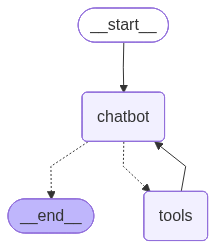

In [14]:
# Step 5: Compile the Graph
graph= graph_builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

### Step 6: Launch the Gradio Chat Interface (No Memory Yet)

At this point the chatbot can use tools, but **has no cross-turn memory** —
each `graph.invoke()` call starts fresh. The Gradio `history` parameter is present
for UI compatibility but is not passed into the graph.

In [15]:
def chat(user_input: str, history):
    result= graph.invoke({"messages": [{"role": "user", "content": user_input}]})
    return result["messages"][-1].content 

gr.ChatInterface(chat, type="messages").launch()

* Running on local URL:  http://127.0.0.1:7860

To create a public link, set `share=True` in `launch()`.


## Adding Memory to the Graph

### Why doesn't the graph already remember past turns?

The `add_messages` reducer appends messages **within a single `invoke()` call** (one super-step),
but state is discarded between calls. Each `invoke()` starts a fresh state object.

### What is a Super-Step?

> A super-step is a single full pass through the graph — from START to END, potentially cycling
> through tool nodes. Nodes that run in parallel share one super-step; sequential nodes are
> separate super-steps.

### How Checkpointing Solves This

A **checkpointer** saves the full state to a store (memory or database) after every super-step,
keyed by a `thread_id`. On the next `invoke()`, LangGraph loads the saved state for that thread
and feeds the full message history back in — giving the LLM persistent conversation context.

In [19]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()  # in-RAM checkpointer; state is lost when the process restarts

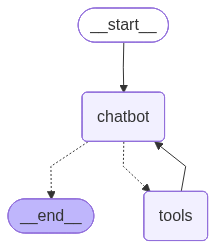

In [20]:
# Steps 1 and 2
graph_builder = StateGraph(State)


# Step 3
llm = ChatOpenAI(model="gpt-4o-mini")
llm_with_tools = llm.bind_tools(tools)

def chatbot(state: State):
    print(state)
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

graph_builder.add_node("chatbot", chatbot)
graph_builder.add_node("tools", ToolNode(tools=tools))

# Step 4
graph_builder.add_conditional_edges( "chatbot", tools_condition, "tools")
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

# Step 5: pass the checkpointer here — this is what enables persistent memory
graph = graph_builder.compile(checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))

In [21]:
# thread_id scopes the memory — same ID = same conversation history across invocations
config= {"configurable": {"thread_id": "1"}}

def chat(user_input: str, history):
    result= graph.invoke({"messages": [{"role":"user", "content": user_input}]}, config=config)

    return result["messages"][-1].content

gr.ChatInterface(chat, type="messages").launch()

* Running on local URL:  http://127.0.0.1:7862

To create a public link, set `share=True` in `launch()`.


{'messages': [HumanMessage(content="what's my name", additional_kwargs={}, response_metadata={}, id='1e124d00-508e-4b3b-9f46-a38d46d25c78')]}


### Inspecting the Checkpointer State

`graph.get_state(config)` returns the **latest snapshot** for the given `thread_id` — useful to
see exactly what the LLM currently has in its context window.

`graph.get_state_history(config)` returns **all snapshots ever saved** for that thread,
from oldest to most recent. Each snapshot is a `StateSnapshot` with:
- `values` — the state dict at that point
- `config` — the `checkpoint_id` you can use to replay from that exact moment
- `next` — which node(s) would run next if you resumed here

In [22]:
# Inspect the current saved state for this thread — shows all messages in memory
graph.get_state(config)

StateSnapshot(values={'messages': [HumanMessage(content="what's my name", additional_kwargs={}, response_metadata={}, id='1e124d00-508e-4b3b-9f46-a38d46d25c78'), AIMessage(content="I don't have access to your personal information, including your name. If you'd like to share your name or any other details, feel free to do so!", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 32, 'prompt_tokens': 92, 'total_tokens': 124, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_ad343dd83e', 'id': 'chatcmpl-DmCgKTJ94QwIQg4m9jlHaCOqiPRoV', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e86f8-0f5d-7f70-9c1e-c85bc9fadbdf-0', tool_calls=[], invalid_tool_calls=[], usage_met

In [23]:
# Returns a list of StateSnapshot objects — one per super-step — showing the full checkpoint history
list(graph.get_state_history(config))

[StateSnapshot(values={'messages': [HumanMessage(content="what's my name", additional_kwargs={}, response_metadata={}, id='1e124d00-508e-4b3b-9f46-a38d46d25c78'), AIMessage(content="I don't have access to your personal information, including your name. If you'd like to share your name or any other details, feel free to do so!", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 32, 'prompt_tokens': 92, 'total_tokens': 124, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_ad343dd83e', 'id': 'chatcmpl-DmCgKTJ94QwIQg4m9jlHaCOqiPRoV', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e86f8-0f5d-7f70-9c1e-c85bc9fadbdf-0', tool_calls=[], invalid_tool_calls=[], usage_me

### LangGraph gives you tools to set the state back to a prior point in time, to branch off:

```
config = {"configurable": {"thread_id": "1", "checkpoint_id": ...}}
graph.invoke(None, config=config)
```

And this allows you to build stable systems that can be recovered and rerun from any prior checkpoint.

### Persistent Memory with SQLite

`MemorySaver` stores checkpoints in RAM — they vanish when the process restarts.
`SqliteSaver` persists them to a local `.db` file, so conversation history survives restarts.

This is a drop-in replacement: just swap `checkpointer=memory` → `checkpointer=sql_memory`.
In production you'd swap this again for a Postgres or Redis checkpointer.

In [27]:
import sqlite3
from langgraph.checkpoint.sqlite import SqliteSaver

db_path= "memory.db"
conn= sqlite3.connect(db_path, check_same_thread=False)  # allow access from multiple threads (Gradio runs async)
sql_memory= SqliteSaver(conn)  # wraps the sqlite connection as a LangGraph-compatible checkpointer




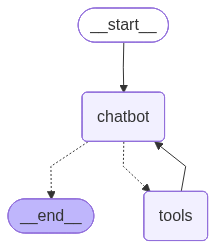

In [28]:
# Steps 1 and 2
graph_builder = StateGraph(State)


# Step 3
llm = ChatOpenAI(model="gpt-4o-mini")
llm_with_tools = llm.bind_tools(tools)

def chatbot(state: State):
    print(state)
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

graph_builder.add_node("chatbot", chatbot)
graph_builder.add_node("tools", ToolNode(tools=tools))

# Step 4
graph_builder.add_conditional_edges( "chatbot", tools_condition, "tools")
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

# Step 5: compile with sql_memory instead of in-RAM memory — state now persists to disk
graph = graph_builder.compile(checkpointer=sql_memory)
display(Image(graph.get_graph().draw_mermaid_png()))
 

In [29]:
# Using thread_id '3' — a different thread means a fresh conversation history in the DB
config = {"configurable": {"thread_id": "3"}}

def chat(user_input: str, history):
    result = graph.invoke({"messages": [{"role": "user", "content": user_input}]}, config=config)
    return result["messages"][-1].content


gr.ChatInterface(chat, type="messages").launch()

* Running on local URL:  http://127.0.0.1:7864

To create a public link, set `share=True` in `launch()`.


{'messages': [HumanMessage(content='my name is vishnu', additional_kwargs={}, response_metadata={}, id='a6c6b6cc-dd82-47d7-9d8c-6f182c6bba29'), AIMessage(content='Nice to meet you, Vishnu! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 94, 'total_tokens': 110, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_ad343dd83e', 'id': 'chatcmpl-DmCbsaYZlVtfSJl3PKV0RAB6iDVrK', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e86f3-d492-77e1-9f57-fcc003058899-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 94, 'output_tokens': 16, 'total_tokens': 110, 'input_token_details': {'audio': 0, 'cach